# Capstone Project - Modelling Feature Set C

This notebook covers building and evaluating models for Feature Set C, which includes the strongest predictors from my EDA.

The main goals of this notebook are to:

1. Build and compare multiple classification models
2. Evaluate model performance using suitable metrics for an imbalanced classification problem
3. Compare models to see which perform best for my data

This notebook is kept separate from the EDA and feature engineering notebooks. The purpose here is to compare models for Feature Set C.


In [1]:
import sklearn
import imblearn
print("sklearn:", sklearn.__version__)
print("imblearn:", imblearn.__version__)

sklearn: 1.9.0
imblearn: 0.14.2


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    VotingClassifier,
    StackingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from imblearn.ensemble import (
    BalancedRandomForestClassifier,
    BalancedBaggingClassifier,
    EasyEnsembleClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [3]:
repo = fetch_ucirepo(id=891)

X_raw = repo.data.features
y_raw = repo.data.targets

df = pd.concat([X_raw, y_raw], axis=1)

print("Dataset loaded successfully.")
print("Original shape:", df.shape)

Dataset loaded successfully.
Original shape: (253680, 22)


In [4]:
# Rename columns into easier format
df = df.rename(columns={
    'HighBP': 'high_bp',
    'HighChol': 'high_chol',
    'CholCheck': 'chol_check',
    'BMI': 'bmi',
    'Smoker': 'smoker',
    'Stroke': 'stroke',
    'HeartDiseaseorAttack': 'heart_disease',
    'PhysActivity': 'phys_activity',
    'Fruits': 'fruits',
    'Veggies': 'veggies',
    'HvyAlcoholConsump': 'heavy_alcohol',
    'AnyHealthcare': 'any_healthcare',
    'NoDocbcCost': 'no_doc_cost',
    'GenHlth': 'general_health',
    'MentHlth': 'mental_health_days',
    'PhysHlth': 'physical_health_days',
    'DiffWalk': 'difficulty_walking',
    'Sex': 'sex',
    'Age': 'age',
    'Education': 'education',
    'Income': 'income',
    'Diabetes_binary': 'diabetes'
})

df.head(

,high_bp,high_chol,chol_check,bmi,smoker,stroke,heart_disease,phys_activity,fruits,veggies,...,no_doc_cost,general_health,mental_health_days,physical_health_days,difficulty_walking,sex,age,education,income,diabetes
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


In [5]:
duplicate_count = df.duplicated().sum()
duplicate_percent = (duplicate_count / len(df)) * 100

print("Duplicate rows:", duplicate_count, "(" + str(round(duplicate_percent, 2)) + "% of the dataset)")

Duplicate rows: 24206 (9.54% of the dataset)


In [6]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after dropping duplicates:", df.shape)

Shape after dropping duplicates: (229474, 22)


In [7]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (229474, 21)
Target shape: (229474,)


In [8]:
target_summary = y.value_counts().to_frame(name='count')
target_summary['percentage'] = (y.value_counts(normalize=True) * 100).round(2)

target_summary

,count,percentage
diabetes,,
0,194377,84.71
1,35097,15.29


## 3.0 Feature Engineering

Feature Set C uses only the strongest predictors from my EDA. I did not include any engineered features for this feature set.


In [9]:
# Feature Set C: reduced feature set based on EDA
# Includes strongest predictors from EDA only
feature_set_c = [
    'bmi',
    'high_bp',
    'high_chol',
    'chol_check',
    'heart_disease',
    'stroke',
    'phys_activity',
    'general_health',
    'mental_health_days',
    'physical_health_days',
    'difficulty_walking',
    'age',
    'education',
    'income',
]

y = df['diabetes']
X_c = df[feature_set_c]

print('Feature Set C shape:', X_c.shape)

Feature Set C shape: (229474, 14)


## 4.0 Modelling Feature Set C

This notebook looks at Feature Set C, which contains 14 features: the strongest predictors from my EDA.


## 4.1 First Model - Logistic Regression

Logistic regression is my first model because it is simple, fast, and easy to interpret.


In [10]:
# Results list - create ONCE at the start of modelling, not inside each model
all_results = []

# Same split settings for every model in this notebook
TEST_SIZE = 0.25
RANDOM_STATE = 42

### Reproducibility settings

- Data: UCI BRFSS 2015 (id=891), duplicates removed → 229,474 rows
- Features: Feature Set C (14 EDA-selected predictors)
- Split: 75/25 stratified, `random_state=42`
- Scaling: `StandardScaler` fit on train only
- Slow models: 20k train subsample (RBF SVM, Balanced Random Forest, Easy Ensemble)
- Ensembles: 30k train subsample (Voting, Stacking)
- Balanced Bagging: full training set
- Evaluation: full test set (57,369 rows)


In [11]:
X = X_c
y = df['diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:")
y_train_balance = y_train.value_counts(normalize=True)
print(y_train_balance.round(4))
print("Test class balance:")
y_test_balance = y_test.value_counts(normalize=True)
print(y_test_balance.round(4))

Train shape: (172105, 14)  Test shape: (57369, 14)
Train class balance:
diabetes
0    0.8471
1    0.1529
Name: proportion, dtype: float64
Test class balance:
diabetes
0    0.8471
1    0.1529
Name: proportion, dtype: float64


In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
log_model = LogisticRegression(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

model = log_model
model_name = "Logistic Regression"

In [14]:
y_train_pred = model.predict(X_train_scaled)
train_acc = accuracy_score(y_train, y_train_pred)

print("Training Accuracy", round(train_acc, 4))
print("Training Classification Report:")
print(classification_report(y_train, y_train_pred, digits=4))

Training Accuracy: 0.7160
Training Classification Report:
              precision    recall  f1-score   support

           0     0.9408    0.7093    0.8088    145782
           1     0.3186    0.7529    0.4478     26323

    accuracy                         0.7160    172105
   macro avg     0.6297    0.7311    0.6283    172105
weighted avg     0.8457    0.7160    0.7536    172105



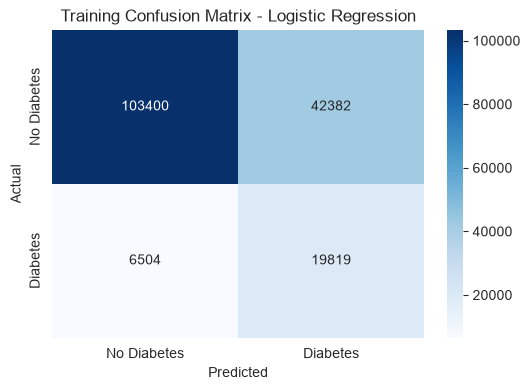

Training Confusion Matrix Breakdown
True Negatives:  103400
False Positives: 42382
False Negatives: 6504
True Positives:  19819


In [15]:
train_cm = confusion_matrix(y_train, y_train_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    train_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)
plt.title(f"Training Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = train_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Training Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

In [16]:
y_test_pred = model.predict(X_test_scaled)
y_test_prob_all = model.predict_proba(X_test_scaled)
y_test_prob = y_test_prob_all[:, 1]

test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, pos_label=1)
test_recall = recall_score(y_test, y_test_pred, pos_label=1)
test_f1 = f1_score(y_test, y_test_pred, pos_label=1)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

print("Test Accuracy", round(test_acc, 4))
print("Precision", round(test_precision, 4))
print("Recall", round(test_recall, 4))
print("F1-score", round(test_f1, 4))
print("ROC AUC", round(test_roc_auc, 4))

print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

Test Accuracy:  0.7139
Precision:      0.3172
Recall:         0.7554
F1-score:       0.4468
ROC AUC:        0.8070

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9412    0.7064    0.8071     48595
           1     0.3172    0.7554    0.4468      8774

    accuracy                         0.7139     57369
   macro avg     0.6292    0.7309    0.6269     57369
weighted avg     0.8457    0.7139    0.7520     57369



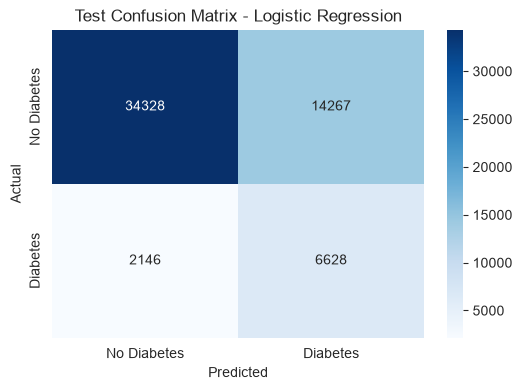

Test Confusion Matrix Breakdown
True Negatives:  34328
False Positives: 14267
False Negatives: 2146
True Positives:  6628
True Positives:  6628


In [17]:
test_cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)
plt.title(f"Test Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = test_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Test Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)
print("True Positives", tp)

In [18]:
logistic_results_c = {
    'Feature Set': 'C',
    'Model': model_name,
    'Training Accuracy': train_acc,
    'Test Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1-score': test_f1,
    'ROC AUC': test_roc_auc,
    'False Positives': fp,
    'False Negatives': fn
}

all_results.append(logistic_results_c)
pd.DataFrame(all_results).round(4)

,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,C,Logistic Regression,0.716,0.7139,0.3172,0.7554,0.4468,0.807,14267,2146


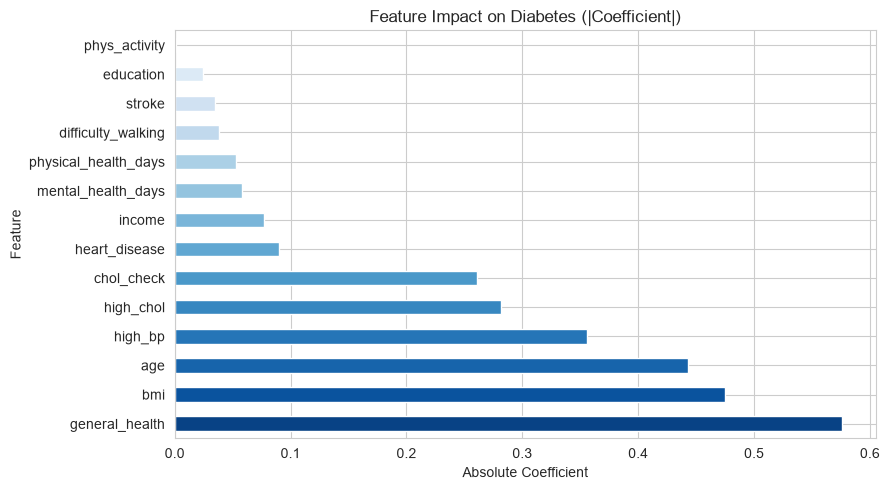

In [19]:
# Which features had the strongest effect (absolute coefficient size)
coef = pd.Series(
    np.abs(log_model.coef_[0]),
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
coef.plot(kind='barh', color=sns.color_palette('Blues_r', len(coef)))
plt.title('Feature Impact on Diabetes (|Coefficient|)')
plt.xlabel('Absolute Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Observation

Logistic regression gives me a strong starting point because it is simple and easy to interpret.

On Feature Set C, the training and test accuracy were very similar (0.716 vs 0.714), showing the model performs well and is not underfitting or overfitting. What I am most interested in for this dataset is the false negatives: cases where the model predicts someone does not have diabetes when they actually do. On the test set, the model had 2,146 false negatives.

Compared with Feature Set A (2,106 false negatives) and Feature Set B (2,094 false negatives), logistic regression on Feature Set C missed slightly more cases. Recall was still similar across all three sets. This suggests that keeping only the 14 strongest predictors did not improve this linear model and may have lost a small amount of signal.

Precision was 0.32, meaning that although accuracy was around 0.71, many of the people flagged as at risk were false alarms. Because of that, I still need to look at other models to see whether more advanced approaches can improve recall further or capture non-linear patterns better.


## 4.2 Second Model - Support Vector Machines - Linear Kernel

Linear SVM is my second model. Like logistic regression, it finds a linear decision boundary, but it uses a different approach (maximising the margin between classes).

I am using `LinearSVC` instead of `SVC(kernel='linear')` because it trains faster on large datasets like mine.

For ROC AUC, Linear SVM does not give probabilities, so I use `decision_function` scores instead.


In [20]:
# Train/test split and scaling already set up in Section 4.1
# Reusing X_train_scaled, X_test_scaled, y_train, y_test
print("Reusing existing split - Train:", X_train.shape, " Test:", X_test.shape)

Reusing existing split - Train: (172105, 14)  Test: (57369, 14)


In [21]:
# X_train_scaled and X_test_scaled already created in Section 4.1

In [22]:
from sklearn.svm import LinearSVC

In [23]:
linear_svm_model = LinearSVC(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    max_iter=20000
)

linear_svm_model.fit(X_train_scaled, y_train)

model = linear_svm_model
model_name = "Linear SVM"

In [24]:
y_train_pred = model.predict(X_train_scaled)
train_acc = accuracy_score(y_train, y_train_pred)

print("Training Accuracy", round(train_acc, 4))
print("Training Classification Report:")
print(classification_report(y_train, y_train_pred, digits=4))

Training Accuracy: 0.7122

Training Classification Report:
              precision    recall  f1-score   support

           0     0.9416    0.7039    0.8056    145782
           1     0.3161    0.7580    0.4462     26323

    accuracy                         0.7122    172105
   macro avg     0.6288    0.7310    0.6259    172105
weighted avg     0.8459    0.7122    0.7506    172105



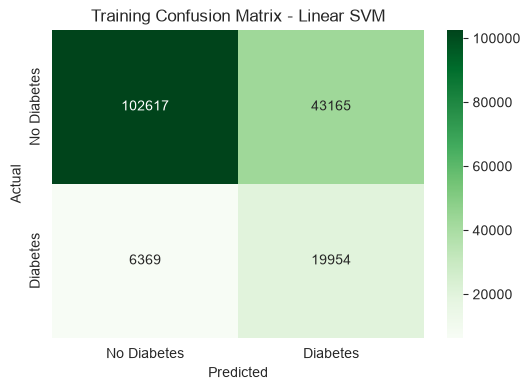

Training Confusion Matrix Breakdown
True Negatives:  102617
False Positives: 43165
False Negatives: 6369
True Positives:  19954


In [25]:
train_cm = confusion_matrix(y_train, y_train_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    train_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)
plt.title(f"Training Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = train_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Training Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

In [26]:
y_test_pred = model.predict(X_test_scaled)

y_test_scores = model.decision_function(X_test_scaled)

test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, pos_label=1)
test_recall = recall_score(y_test, y_test_pred, pos_label=1)
test_f1 = f1_score(y_test, y_test_pred, pos_label=1)
test_roc_auc = roc_auc_score(y_test, y_test_scores)

print("Test Accuracy", round(test_acc, 4))
print("Precision", round(test_precision, 4))
print("Recall", round(test_recall, 4))
print("F1-score", round(test_f1, 4))
print("ROC AUC", round(test_roc_auc, 4))

print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

Test Accuracy:  0.7096
Precision:      0.3142
Recall:         0.7603
F1-score:       0.4447
ROC AUC:        0.8067

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9418    0.7004    0.8034     48595
           1     0.3142    0.7603    0.4447      8774

    accuracy                         0.7096     57369
   macro avg     0.6280    0.7304    0.6240     57369
weighted avg     0.8458    0.7096    0.7485     57369



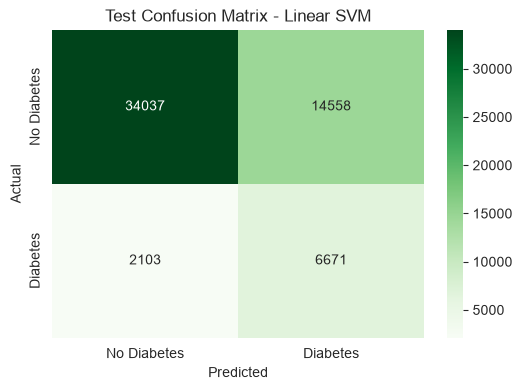

Test Confusion Matrix Breakdown
True Negatives:  34037
False Positives: 14558
False Negatives: 2103
True Positives:  6671


In [27]:
test_cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)
plt.title(f"Test Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = test_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Test Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

In [28]:
linear_svm_results_c = {
    'Feature Set': 'C',
    'Model': model_name,
    'Training Accuracy': train_acc,
    'Test Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1-score': test_f1,
    'ROC AUC': test_roc_auc,
    'False Positives': fp,
    'False Negatives': fn
}

all_results.append(linear_svm_results_c)
pd.DataFrame(all_results).round(4)

,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,C,Logistic Regression,0.7160,0.7139,0.3172,0.7554,0.4468,0.8070,14267,2146
1,C,Linear SVM,0.7122,0.7096,0.3142,0.7603,0.4447,0.8067,14558,2103


### Observation

On Feature Set C, Linear SVM achieved a test recall of 0.7603 with 2,103 false negatives on the full test set.

Compared with logistic regression on the same feature set (recall 0.7554, 2,146 false negatives), Linear SVM caught slightly more diabetes cases. It missed 43 fewer cases, which matters for this project because missing someone at risk is worse than a false alarm.

Both models had very similar overall performance:

- Test accuracy: logistic regression 0.7139 vs Linear SVM 0.7096
- ROC AUC: both around 0.81
- Precision: both around 0.31 (many false positives)

Linear SVM had slightly more false positives (14,558 vs 14,267), which is the trade-off from using `class_weight='balanced'` to push recall higher.

Compared with Feature Sets A and B, Linear SVM on Feature Set C performed a little worse. On Set A it had recall 0.7654 with 2,058 false negatives, and on Set B recall 0.7683 with 2,033 false negatives. The reduced 14-feature set may have lost a small amount of predictive signal for this linear model.

Overall, Linear SVM is slightly stronger than logistic regression on Feature Set C for recall and false negatives, which is my main priority for diabetes screening. I will keep both models in the project for comparison.


## 4.3 Third Model - RBF SVM

RBF SVM can capture non-linear patterns that logistic regression and Linear SVM cannot.

Because RBF SVM is very slow on large datasets, I train on a stratified subsample of 20,000 rows and evaluate on the full test set (57,369 rows).

Important:

- I did not use `probability=True` because it can take a long time on large data.
- I use `decision_function` for ROC AUC instead of `predict_proba`.

In [29]:
X_train_sub, X_train_sub_rest, y_train_sub, y_train_sub_rest = train_test_split(
    X_train_scaled,
    y_train,
    train_size=20000,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("Train subsample shape:", X_train_sub.shape)
print("Train subsample class balance:")
y_train_sub_balance = y_train_sub.value_counts(normalize=True)
print(y_train_sub_balance.round(4))

Train subsample shape: (20000, 14)

Train subsample class balance:
diabetes
0    0.847
1    0.153
Name: proportion, dtype: float64


In [30]:
rbf_svm_model = SVC(
    kernel='rbf',
    C=0.3,
    gamma='scale',
    class_weight='balanced',
    random_state=RANDOM_STATE
)

rbf_svm_model.fit(X_train_sub, y_train_sub)

model = rbf_svm_model
model_name = "RBF SVM"

In [31]:
y_train_pred = model.predict(X_train_sub)
train_acc = accuracy_score(y_train_sub, y_train_pred)

print("Training Accuracy", round(train_acc, 4))
print("Training Classification Report:")
print(classification_report(y_train_sub, y_train_pred, digits=4))

Training Accuracy: 0.7140

Training Classification Report:
              precision    recall  f1-score   support

           0     0.9508    0.6985    0.8054     16941
           1     0.3239    0.7999    0.4611      3059

    accuracy                         0.7140     20000
   macro avg     0.6374    0.7492    0.6333     20000
weighted avg     0.8549    0.7140    0.7527     20000



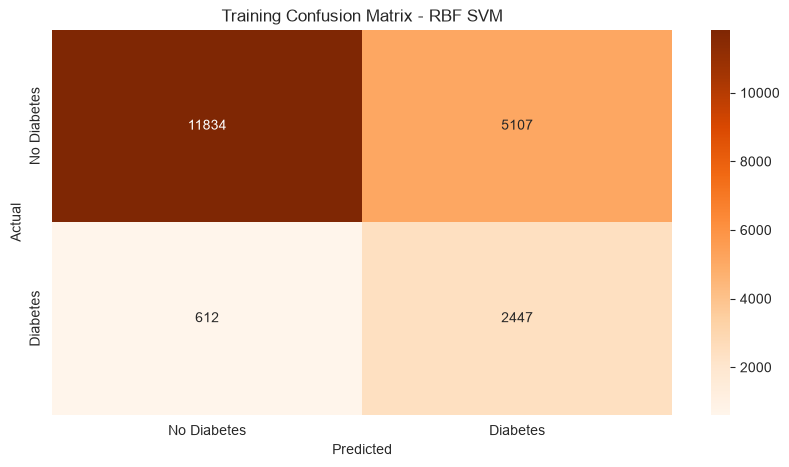

Training Confusion Matrix Breakdown
True Negatives: 11834
False Positives: 5107
False Negatives: 612
True Positives: 2447


In [32]:
train_cm = confusion_matrix(y_train_sub, y_train_pred)

sns.heatmap(
    train_cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)
plt.title(f"Training Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = train_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Training Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

In [33]:
y_test_pred = model.predict(X_test_scaled)
y_test_scores = model.decision_function(X_test_scaled)

test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, pos_label=1)
test_recall = recall_score(y_test, y_test_pred, pos_label=1)
test_f1 = f1_score(y_test, y_test_pred, pos_label=1)
test_roc_auc = roc_auc_score(y_test, y_test_scores)

print("Test Accuracy", round(test_acc, 4))
print("Precision", round(test_precision, 4))
print("Recall", round(test_recall, 4))
print("F1-score", round(test_f1, 4))
print("ROC AUC", round(test_roc_auc, 4))

print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

Test Accuracy:  0.6994
Precision:      0.3082
Recall:         0.7760
F1-score:       0.4412
ROC AUC:        0.7984

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9443    0.6855    0.7944     48595
           1     0.3082    0.7760    0.4412      8774

    accuracy                         0.6994     57369
   macro avg     0.6263    0.7308    0.6178     57369
weighted avg     0.8470    0.6994    0.7404     57369



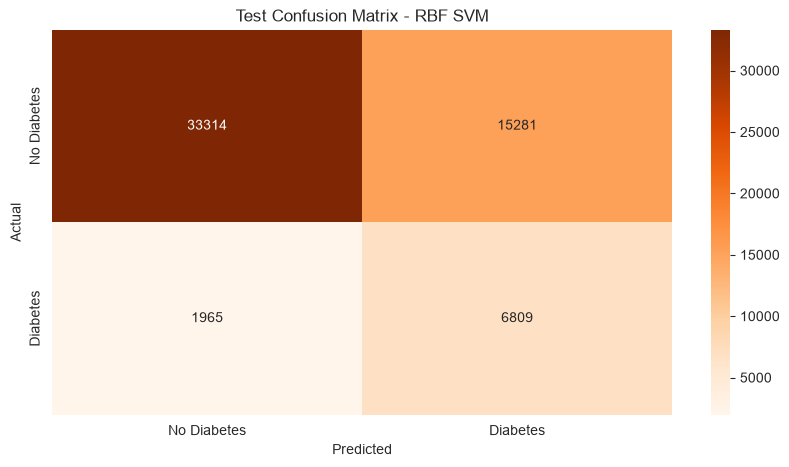

Test Confusion Matrix Breakdown
True Negatives: 33314
False Positives: 15281
False Negatives: 1965
True Positives: 6809


In [34]:
test_cm = confusion_matrix(y_test, y_test_pred)

sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)
plt.title(f"Test Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = test_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Test Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

In [35]:
rbf_svm_results_c = {
    'Feature Set': 'C',
    'Model': model_name,
    'Training Accuracy': train_acc,
    'Test Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1-score': test_f1,
    'ROC AUC': test_roc_auc,
    'False Positives': fp,
    'False Negatives': fn
}

all_results.append(rbf_svm_results_c)
pd.DataFrame(all_results).round(4)

,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,C,Logistic Regression,0.7160,0.7139,0.3172,0.7554,0.4468,0.8070,14267,2146
1,C,Linear SVM,0.7122,0.7096,0.3142,0.7603,0.4447,0.8067,14558,2103
2,C,RBF SVM,0.7140,0.6994,0.3082,0.7760,0.4412,0.7984,15281,1965


### Observation


On Feature Set C, RBF SVM reached a test recall of 0.7760 with 1,965 false negatives. This was the strongest recall so far on this feature set, meaning it caught the most diabetes cases among the practical models, which is the main priority for this project.

Compared with Linear SVM (2,103 false negatives) and logistic regression (2,146 false negatives) on Feature Set C, RBF SVM missed fewer cases but produced more false positives (15,281). Test accuracy dropped slightly to 0.6994 and precision to 0.3082, showing the trade-off for higher sensitivity. ROC AUC was 0.7984, a little lower than the linear models.

Across feature sets, RBF SVM on Feature Set C was the strongest practical result in the whole project. It beat Feature Set A (recall 0.7746, 1,978 false negatives) and Feature Set B (recall 0.7678, 2,037 false negatives) on both recall and false negatives. So the reduced 14-feature set did not hurt this model; if anything, it helped it edge ahead while staying simpler to deploy.

Overall, RBF SVM delivered the best recall on Feature Set C and is my leading candidate for a practical screening model.


## 4.4 Fourth Model - Gaussian Naive Bayes


Gaussian Naive Bayes is a fast probabilistic benchmark. It assumes features are independent, which is not fully true for health data (BMI, blood pressure, and similar factors are related), but it is still useful for comparison.

Because it is very fast, I train on the full train set (not a subsample).


In [36]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
model = nb_model
model_name = "Gaussian Naive Bayes"

In [37]:
y_train_pred = model.predict(X_train_scaled)
train_acc = accuracy_score(y_train, y_train_pred)

print("Training Accuracy", round(train_acc, 4))
print("Training Classification Report:")
print(classification_report(y_train, y_train_pred, digits=4))

Training Accuracy: 0.7631

Training Classification Report:
              precision    recall  f1-score   support

           0     0.9057    0.8041    0.8519    145782
           1     0.3308    0.5361    0.4091     26323

    accuracy                         0.7631    172105
   macro avg     0.6182    0.6701    0.6305    172105
weighted avg     0.8177    0.7631    0.7842    172105



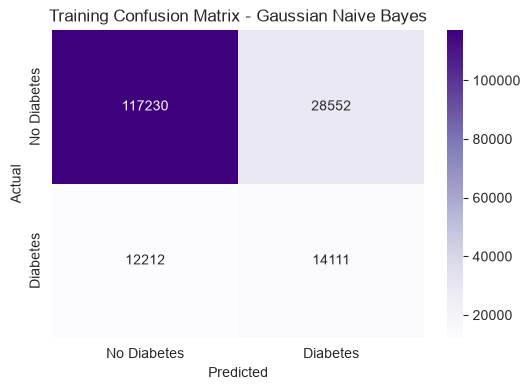

Training Confusion Matrix Breakdown
True Negatives:  117230
False Positives: 28552
False Negatives: 12212
True Positives:  14111


In [38]:
train_cm = confusion_matrix(y_train, y_train_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    train_cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)
plt.title(f"Training Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = train_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Training Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

In [39]:
y_test_pred = model.predict(X_test_scaled)
y_test_prob_all = model.predict_proba(X_test_scaled)
y_test_prob = y_test_prob_all[:, 1]

test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, pos_label=1)
test_recall = recall_score(y_test, y_test_pred, pos_label=1)
test_f1 = f1_score(y_test, y_test_pred, pos_label=1)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

print("Test Accuracy", round(test_acc, 4))
print("Precision", round(test_precision, 4))
print("Recall", round(test_recall, 4))
print("F1-score", round(test_f1, 4))
print("ROC AUC", round(test_roc_auc, 4))
print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

Test Accuracy:  0.7637
Precision:      0.3328
Recall:         0.5426
F1-score:       0.4125
ROC AUC:        0.7741

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9068    0.8036    0.8521     48595
           1     0.3328    0.5426    0.4125      8774

    accuracy                         0.7637     57369
   macro avg     0.6198    0.6731    0.6323     57369
weighted avg     0.8190    0.7637    0.7848     57369



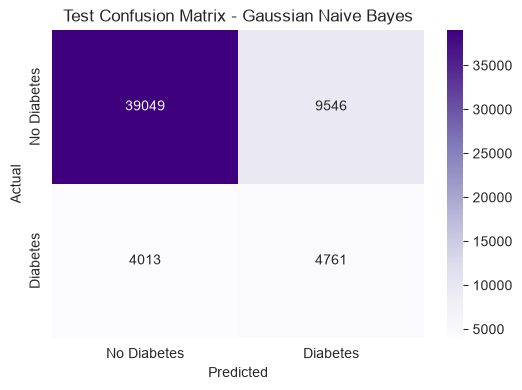

Test Confusion Matrix Breakdown
True Negatives:  39049
False Positives: 9546
False Negatives: 4013
True Positives:  4761


In [40]:
test_cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)
plt.title(f"Test Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = test_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Test Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

### Observation

Gaussian Naive Bayes on Feature Set C achieved a test accuracy of 0.764 and recall of 0.543, with 4,013 false negatives. While accuracy was higher than the SVM and logistic regression models, recall dropped, meaning it missed far more diabetes cases. Precision was 0.333, slightly better than the other models, showing fewer false alarms but at the cost of sensitivity.

Compared with Feature Set A (recall 0.577, 3,711 false negatives) and Feature Set B (recall 0.604, 3,474 false negatives), performance declined further on Feature Set C. The reduced feature set seems to have weakened this model's ability to detect positive cases, which makes sense since Naive Bayes relies heavily on feature independence and can benefit from a broader range of inputs.

Overall, Gaussian Naive Bayes remained fast and stable but was the weakest model for recall on Feature Set C. It is still useful as a benchmark for comparison, but not suitable for screening where missing cases is the main concern.


In [41]:
nb_results_c = {
    'Feature Set': 'C',
    'Model': model_name,
    'Training Accuracy': train_acc,
    'Test Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1-score': test_f1,
    'ROC AUC': test_roc_auc,
    'False Positives': fp,
    'False Negatives': fn
}

all_results.append(nb_results_c)
pd.DataFrame(all_results).round(4)

,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,C,Logistic Regression,0.7160,0.7139,0.3172,0.7554,0.4468,0.8070,14267,2146
1,C,Linear SVM,0.7122,0.7096,0.3142,0.7603,0.4447,0.8067,14558,2103
2,C,RBF SVM,0.7140,0.6994,0.3082,0.7760,0.4412,0.7984,15281,1965
3,C,Gaussian Naive Bayes,0.7631,0.7637,0.3328,0.5426,0.4125,0.7741,9546,4013


## 5.0 Ensemble Methods


### Ensemble Models Overview

Ensemble methods combine multiple models to improve predictive performance.

This project uses five ensemble approaches:

1. Balanced Random Forest - builds decision trees on balanced bootstrap samples to improve minority-class detection.
2. Balanced Bagging - trains base learners on balanced subsets and averages their predictions to reduce variance and bias.
3. Easy Ensemble - creates several balanced subsets and applies boosting to each, enhancing recall for imbalanced datasets.
4. Voting Classifier - combines predictions from multiple models using soft voting to produce a more stable final probability.
5. Stacking Classifier - trains a meta-model on the outputs of base models to learn the best way to combine predictions.

### 5.1 Balanced Random Forest

Balanced Random Forest is a variant of the Random Forest algorithm designed for imbalanced datasets.

It builds multiple decision trees using balanced bootstrap samples. Each tree is trained on a subset where the minority and majority classes are equally represented.

This helps prevent bias toward the majority class (non-diabetes) and improves recall for the minority class (diabetes).


In [42]:
brf_model = BalancedRandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

brf_model.fit(X_train_sub, y_train_sub)

model = brf_model
model_name = "Balanced Random Forest"

In [43]:
y_train_pred = model.predict(X_train_sub)
train_acc = accuracy_score(y_train_sub, y_train_pred)

print("Training Accuracy", round(train_acc, 4))
print("Training Classification Report:")
print(classification_report(y_train_sub, y_train_pred, digits=4))

Training Accuracy: 0.8868

Training Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.8663    0.9284     16941
           1     0.5746    1.0000    0.7298      3059

    accuracy                         0.8868     20000
   macro avg     0.7873    0.9332    0.8291     20000
weighted avg     0.9349    0.8868    0.8980     20000



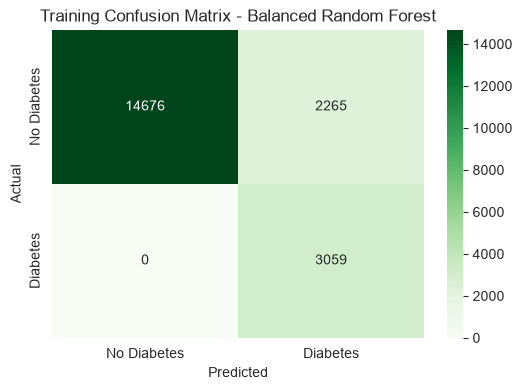

Training Confusion Matrix Breakdown
True Negatives:  14676
False Positives: 2265
False Negatives: 0
True Positives:  3059


In [44]:
train_cm = confusion_matrix(y_train_sub, y_train_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    train_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title(f"Training Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = train_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Training Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

In [45]:
y_test_pred = model.predict(X_test)
y_test_proba_all = model.predict_proba(X_test)
y_test_proba = y_test_proba_all[:, 1]

test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_proba)

print("Test Accuracy", round(test_acc, 4))
print("Test Precision", round(test_precision, 4))
print("Test Recall", round(test_recall, 4))
print("Test F1 Score", round(test_f1, 4))
print("Test ROC AUC", round(test_roc_auc, 4))

print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

Test Accuracy: 0.4206
Test Precision: 0.2000
Test Recall: 0.9295
Test F1 Score: 0.3291
Test ROC AUC: 0.7057

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9627    0.3287    0.4900     48595
           1     0.2000    0.9295    0.3291      8774

    accuracy                         0.4206     57369
   macro avg     0.5813    0.6291    0.4096     57369
weighted avg     0.8460    0.4206    0.4654     57369



### Observation

Balanced Random Forest achieved a very high recall of 0.93 on Feature Set C, with only 619 false negatives.

This means it caught almost all diabetes cases, which is ideal for minimising missed positives. However, this came at a cost test accuracy dropped to 0.42 and precision to 0.20, with 32,623 false positives. The model flagged far too many people as diabetic, making it impractical for real screening.

Compared with Feature Set A (recall 0.97, 290 false negatives) and Feature Set B (recall 0.80, 1,764 false negatives), performance on C was still heavily skewed toward recall. The reduced feature set slightly lowered sensitivity but did not fix the over-prediction problem.

Overall, Balanced Random Forest remains powerful for recall but unreliable for precision. It is useful for comparison but not suitable as a final model for this dataset.

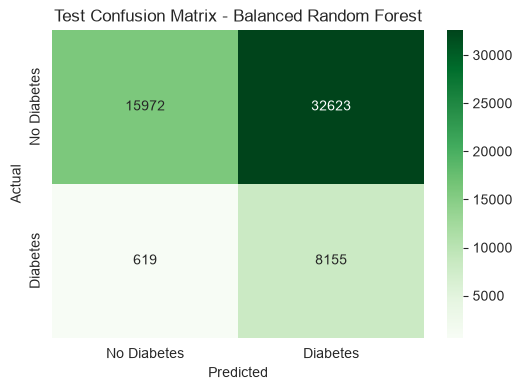

Test Confusion Matrix Breakdown
True Negatives:  15972
False Positives: 32623
False Negatives: 619
True Positives:  8155


In [46]:
test_cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title(f"Test Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = test_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Test Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

In [47]:
brf_results_c = {
    'Feature Set': 'C',
    'Model': model_name,
    'Training Accuracy': train_acc,
    'Test Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1-score': test_f1,
    'ROC AUC': test_roc_auc,
    'False Positives': fp,
    'False Negatives': fn
}

all_results.append(brf_results_c)
pd.DataFrame(all_results).round(4)

,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,C,Logistic Regression,0.7160,0.7139,0.3172,0.7554,0.4468,0.8070,14267,2146
1,C,Linear SVM,0.7122,0.7096,0.3142,0.7603,0.4447,0.8067,14558,2103
2,C,RBF SVM,0.7140,0.6994,0.3082,0.7760,0.4412,0.7984,15281,1965
3,C,Gaussian Naive Bayes,0.7631,0.7637,0.3328,0.5426,0.4125,0.7741,9546,4013
4,C,Balanced Random Forest,0.8868,0.4206,0.2000,0.9295,0.3291,0.7057,32623,619


### 5.2 Balanced Bagging


Balanced Bagging combines the idea of bagging (bootstrap aggregation) with class balancing.

Each base estimator (often a decision tree) is trained on a balanced subset of the data, improving sensitivity to minority cases.

Predictions are averaged across all estimators to reduce variance and improve stability.


In [48]:
bbb_model = BalancedBaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    n_estimators=50,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

bbb_model.fit(X_train, y_train)

model = bbb_model
model_name = "Balanced Bagging"

In [49]:
y_train_pred = model.predict(X_train)

train_acc = accuracy_score(y_train, y_train_pred)

print("Training Accuracy", round(train_acc, 4))
print("Training Classification Report:")
print(classification_report(y_train, y_train_pred, digits=4))

Training Accuracy: 0.7227

Training Classification Report:
              precision    recall  f1-score   support

           0     0.9524    0.7080    0.8122    145782
           1     0.3321    0.8040    0.4700     26323

    accuracy                         0.7227    172105
   macro avg     0.6422    0.7560    0.6411    172105
weighted avg     0.8575    0.7227    0.7599    172105



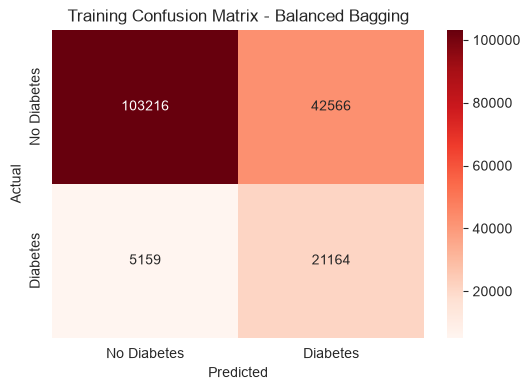

Training Confusion Matrix Breakdown
True Negatives:  103216
False Positives: 42566
False Negatives: 5159
True Positives:  21164


In [50]:
train_cm = confusion_matrix(y_train, y_train_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    train_cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title(f"Training Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = train_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Training Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

In [51]:
y_test_pred = model.predict(X_test)

test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("Test Accuracy", round(test_acc, 4))
print("Test Precision", round(test_precision, 4))
print("Test Recall", round(test_recall, 4))
print("Test F1 Score", round(test_f1, 4))

print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

Test Accuracy: 0.7103
Test Precision: 0.3165
Test Recall: 0.7710
Test F1 Score: 0.4487

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9442    0.6993    0.8035     48595
           1     0.3165    0.7710    0.4487      8774

    accuracy                         0.7103     57369
   macro avg     0.6303    0.7352    0.6261     57369
weighted avg     0.8482    0.7103    0.7492     57369



In [52]:
y_test_proba_all = model.predict_proba(X_test)
y_test_proba = y_test_proba_all[:, 1]
test_roc_auc = roc_auc_score(y_test, y_test_proba)

print("Test ROC-AUC", round(test_roc_auc, 4))

Test ROC-AUC: 0.8116


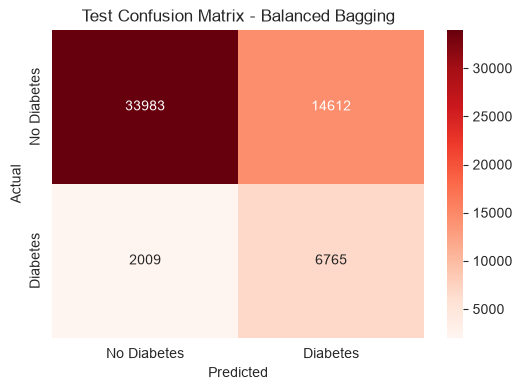

Test Confusion Matrix Breakdown
True Negatives:  33983
False Positives: 14612
False Negatives: 2009
True Positives:  6765


In [53]:
test_cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title(f"Test Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = test_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Test Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

### Observation

Balanced Bagging performed well on Feature Set C, achieving a test accuracy of 0.710 and recall of 0.771 with 2,009 false negatives. This shows the model detected most diabetes cases while keeping false positives (14,612) at a more manageable level than the ensembles. Precision was 0.317, similar to the linear models, meaning it still produced some false alarms but maintained strong sensitivity.

Compared with Feature Set A (recall 0.774, 1,984 false negatives) and Feature Set B (recall 0.775, 1,978 false negatives), performance was almost identical. The reduced feature set did not hurt recall much, suggesting the model generalises well even with fewer predictors. ROC AUC (0.812) was also consistent across all sets, showing stable discrimination between classes.

Overall, Balanced Bagging remains one of the most reliable models for this project. It balances recall and precision better than the more aggressive ensemble methods, making it a strong candidate for screening use.


In [54]:
bbb_results_c = {
    'Feature Set': 'C',
    'Model': model_name,
    'Training Accuracy': train_acc,
    'Test Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1-score': test_f1,
    'ROC AUC': test_roc_auc,
    'False Positives': fp,
    'False Negatives': fn
}

all_results.append(bbb_results_c)
pd.DataFrame(all_results).round(4)

,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,C,Logistic Regression,0.7160,0.7139,0.3172,0.7554,0.4468,0.8070,14267,2146
1,C,Linear SVM,0.7122,0.7096,0.3142,0.7603,0.4447,0.8067,14558,2103
2,C,RBF SVM,0.7140,0.6994,0.3082,0.7760,0.4412,0.7984,15281,1965
3,C,Gaussian Naive Bayes,0.7631,0.7637,0.3328,0.5426,0.4125,0.7741,9546,4013
4,C,Balanced Random Forest,0.8868,0.4206,0.2000,0.9295,0.3291,0.7057,32623,619
5,C,Balanced Bagging,0.7227,0.7103,0.3165,0.7710,0.4487,0.8116,14612,2009


### 5.3 Easy Ensemble


The Easy Ensemble method is specifically designed for highly imbalanced datasets.

It creates multiple balanced subsets of the majority class, trains an AdaBoost classifier on each, and then aggregates their predictions.

This approach combines boosting's ability to focus on hard-to-classify cases with balanced sampling to improve minority recall.


In [55]:
easy_model = EasyEnsembleClassifier(
    n_estimators=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

easy_model.fit(X_train_sub, y_train_sub)

model = easy_model
model_name = "Easy Ensemble"

In [56]:
y_train_pred = model.predict(X_train_sub)
train_acc = accuracy_score(y_train_sub, y_train_pred)

print("Training Accuracy", round(train_acc, 4))
print("Training Classification Report:")
print(classification_report(y_train_sub, y_train_pred, digits=4))

Training Accuracy: 0.7221

Training Classification Report:
              precision    recall  f1-score   support

           0     0.9442    0.7141    0.8132     16941
           1     0.3261    0.7663    0.4575      3059

    accuracy                         0.7221     20000
   macro avg     0.6352    0.7402    0.6354     20000
weighted avg     0.8497    0.7221    0.7588     20000



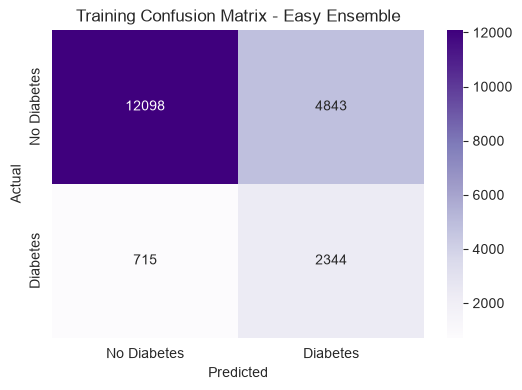

Training Confusion Matrix Breakdown
True Negatives:  12098
False Positives: 4843
False Negatives: 715
True Positives:  2344


In [57]:
train_cm = confusion_matrix(y_train_sub, y_train_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    train_cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title(f"Training Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

tn_train, fp_train, fn_train, tp_train = train_cm.ravel()

print("Training Confusion Matrix Breakdown")
print("True Negatives", tn_train)
print("False Positives", fp_train)
print("False Negatives", fn_train)
print("True Positives", tp_train)

In [58]:
y_test_pred = model.predict(X_test)
y_test_prob_all = model.predict_proba(X_test)
y_test_prob = y_test_prob_all[:, 1]

test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, pos_label=1)
test_recall = recall_score(y_test, y_test_pred, pos_label=1)
test_f1 = f1_score(y_test, y_test_pred, pos_label=1)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

print("Test Accuracy", round(test_acc, 4))
print("Test Precision", round(test_precision, 4))
print("Test Recall", round(test_recall, 4))
print("Test F1 Score", round(test_f1, 4))
print("Test ROC AUC", round(test_roc_auc, 4))

print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

Test Accuracy: 0.1529
Test Precision: 0.1529
Test Recall: 1.0000
Test F1 Score: 0.2653
Test ROC AUC: 0.7373

Test Classification Report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000     48595
           1     0.1529    1.0000    0.2653      8774

    accuracy                         0.1529     57369
   macro avg     0.0765    0.5000    0.1327     57369
weighted avg     0.0234    0.1529    0.0406     57369



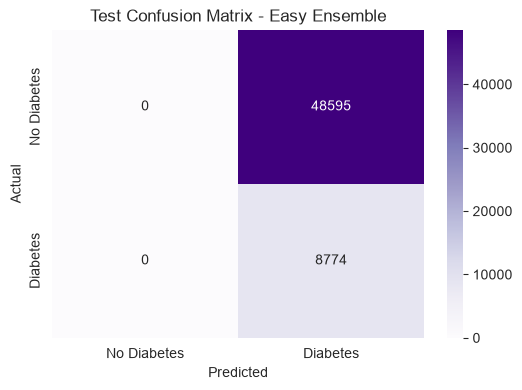

Test Confusion Matrix Breakdown
True Negatives:  0
False Positives: 48595
False Negatives: 0
True Positives:  8774


In [59]:
test_cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title(f"Test Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = test_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Test Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

### Observation

Easy Ensemble reached a perfect recall of 1.00 on Feature Set C, meaning it detected every diabetes case and had 0 false negatives. While that sounds ideal, the trade-off was extreme. Test accuracy dropped to 0.15 and precision to 0.15, with 48,595 false positives. The model flagged nearly everyone as diabetic, making it unusable for real screening.

Compared with Feature Set A (recall 1.00, 0 false negatives, 48,595 false positives) and Feature Set B (recall 0.98, 144 false negatives, 42,045 false positives), this version again pushed recall to the extreme and lost all practical balance. The reduced feature set did not help control over-prediction, showing that Easy Ensemble remains too aggressive regardless of input size.

Overall, Easy Ensemble achieved the highest possible recall but at the cost of practicality. It is useful for demonstrating the upper limit of sensitivity but not suitable for deployment.


In [60]:
easy_results_c = {
    'Feature Set': 'C',
    'Model': model_name,
    'Training Accuracy': train_acc,
    'Test Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1-score': test_f1,
    'ROC AUC': test_roc_auc,
    'False Positives': fp,
    'False Negatives': fn
}

all_results.append(easy_results_c)
pd.DataFrame(all_results).round(4)

,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,C,Logistic Regression,0.7160,0.7139,0.3172,0.7554,0.4468,0.8070,14267,2146
1,C,Linear SVM,0.7122,0.7096,0.3142,0.7603,0.4447,0.8067,14558,2103
2,C,RBF SVM,0.7140,0.6994,0.3082,0.7760,0.4412,0.7984,15281,1965
3,C,Gaussian Naive Bayes,0.7631,0.7637,0.3328,0.5426,0.4125,0.7741,9546,4013
4,C,Balanced Random Forest,0.8868,0.4206,0.2000,0.9295,0.3291,0.7057,32623,619
5,C,Balanced Bagging,0.7227,0.7103,0.3165,0.7710,0.4487,0.8116,14612,2009
6,C,Easy Ensemble,0.7221,0.1529,0.1529,1.0000,0.2653,0.7373,48595,0


### 5.4 Voting Classifier

A Voting Classifier combines predictions from multiple base models (for example logistic regression, SVM, and Naive Bayes) to form a consensus.

In soft voting, it averages predicted probabilities rather than hard class labels, allowing models with higher confidence to influence the final decision more strongly.


In [61]:
X_train_sub, X_train_sub_rest, y_train_sub, y_train_sub_rest = train_test_split(
    X_train_scaled,
    y_train,
    train_size=30000,
    random_state=RANDOM_STATE,
    stratify=y_train
)

voting_estimators = [
    ('lr', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE
    )),
    ('nb', GaussianNB()),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
]

voting_model = VotingClassifier(
    estimators=voting_estimators,
    voting='soft'
)

voting_model.fit(X_train_sub, y_train_sub)

model = voting_model
model_name = "Voting Classifier"

In [62]:
y_train_pred = model.predict(X_train_sub)
train_acc = accuracy_score(y_train_sub, y_train_pred)

print("Training Accuracy", round(train_acc, 4))
print("Training Classification Report:")
print(classification_report(y_train_sub, y_train_pred, digits=4))

Training Accuracy: 0.8339

Training Classification Report:
              precision    recall  f1-score   support

           0     0.9607    0.8382    0.8953     25412
           1     0.4748    0.8102    0.5987      4588

    accuracy                         0.8339     30000
   macro avg     0.7177    0.8242    0.7470     30000
weighted avg     0.8864    0.8339    0.8499     30000



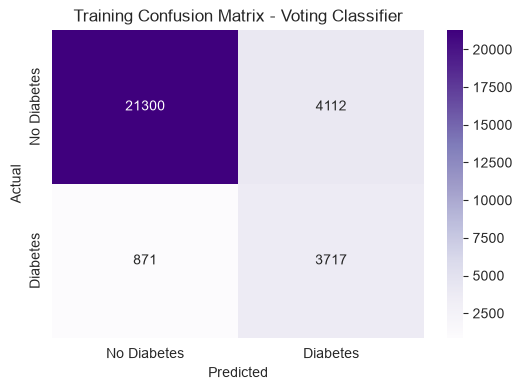

Training Confusion Matrix Breakdown
True Negatives:  21300
False Positives: 4112
False Negatives: 871
True Positives:  3717


In [63]:
train_cm = confusion_matrix(y_train_sub, y_train_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    train_cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title(f"Training Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

tn_train, fp_train, fn_train, tp_train = train_cm.ravel()

print("Training Confusion Matrix Breakdown")
print("True Negatives", tn_train)
print("False Positives", fp_train)
print("False Negatives", fn_train)
print("True Positives", tp_train)

In [64]:
y_test_pred = model.predict(X_test_scaled)
y_test_prob_all = model.predict_proba(X_test_scaled)
y_test_prob = y_test_prob_all[:, 1]

test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

print("Test Accuracy", round(test_acc, 4))
print("Precision", round(test_precision, 4))
print("Recall", round(test_recall, 4))
print("F1-score", round(test_f1, 4))
print("ROC AUC", round(test_roc_auc, 4))

print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

Test Accuracy: 0.7725
Precision: 0.3540
Recall: 0.5913
F1-score: 0.4429
ROC AUC: 0.7967

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9160    0.8052    0.8570     48595
           1     0.3540    0.5913    0.4429      8774

    accuracy                         0.7725     57369
   macro avg     0.6350    0.6982    0.6499     57369
weighted avg     0.8301    0.7725    0.7937     57369



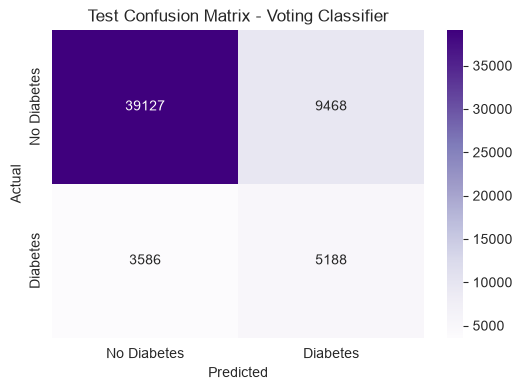

Test Confusion Matrix Breakdown
True Negatives:  39127
False Positives: 9468
False Negatives: 3586
True Positives:  5188


In [65]:
test_cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title(f"Test Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = test_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Test Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

### Observation

The Voting Classifier achieved a test accuracy of 0.773 and recall of 0.591 on Feature Set C, with 3,586 false negatives. It struck a better balance between accuracy and precision than most models, reaching 0.354 precision and 0.443 F1-score. This shows it was more reliable overall, though it missed more diabetes cases than the recall-focused models.

Compared with Feature Set A (accuracy 0.767, recall 0.610, 3,424 false negatives) and Feature Set B (accuracy 0.764, recall 0.626, 3,284 false negatives), performance was similar. The reduced feature set did not change results much, suggesting the ensemble's strength comes from combining models rather than the number of features.

Overall, the Voting Classifier provided a more accuracy-focused, practical performance on Feature Set C. It is less sensitive than the recall-heavy models but more practical if false alarms matter more than catching every case. For this project, where missed cases matter most, it is not my preferred screening model.


In [66]:
voting_results_c = {
    'Feature Set': 'C',
    'Model': model_name,
    'Training Accuracy': train_acc,
    'Test Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1-score': test_f1,
    'ROC AUC': test_roc_auc,
    'False Positives': fp,
    'False Negatives': fn
}

all_results.append(voting_results_c)
pd.DataFrame(all_results).round(4)

,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,C,Logistic Regression,0.7160,0.7139,0.3172,0.7554,0.4468,0.8070,14267,2146
1,C,Linear SVM,0.7122,0.7096,0.3142,0.7603,0.4447,0.8067,14558,2103
2,C,RBF SVM,0.7140,0.6994,0.3082,0.7760,0.4412,0.7984,15281,1965
3,C,Gaussian Naive Bayes,0.7631,0.7637,0.3328,0.5426,0.4125,0.7741,9546,4013
4,C,Balanced Random Forest,0.8868,0.4206,0.2000,0.9295,0.3291,0.7057,32623,619
5,C,Balanced Bagging,0.7227,0.7103,0.3165,0.7710,0.4487,0.8116,14612,2009
6,C,Easy Ensemble,0.7221,0.1529,0.1529,1.0000,0.2653,0.7373,48595,0
7,C,Voting Classifier,0.8339,0.7725,0.3540,0.5913,0.4429,0.7967,9468,3586


### 5.5 Stacking Classifier


Stacking is a two-level ensemble method.

Base models (level 1) make predictions, and a meta-model (level 2) learns how to best combine those predictions.

The meta-model can capture relationships between model outputs, often improving accuracy and generalisation.


In [67]:
X_train_sub_scaled, X_train_sub_scaled_rest, y_train_sub, y_train_sub_rest = train_test_split(
    X_train_scaled,
    y_train,
    train_size=30000,
    random_state=RANDOM_STATE,
    stratify=y_train
)

stacking_estimators = [
    ('lr', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE
    )),
    ('nb', GaussianNB()),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
]

stacking_model = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    cv=3
)

stacking_model.fit(X_train_sub_scaled, y_train_sub)

model = stacking_model
model_name = "Stacking Classifier"

In [68]:
y_train_pred = model.predict(X_train_sub_scaled)
train_acc = accuracy_score(y_train_sub, y_train_pred)

print("Training Accuracy", round(train_acc, 4))
print("Training Classification Report:")
print(classification_report(y_train_sub, y_train_pred, digits=4))

Training Accuracy: 0.7586

Training Classification Report:
              precision    recall  f1-score   support

           0     0.9681    0.7394    0.8384     25412
           1     0.3747    0.8649    0.5229      4588

    accuracy                         0.7586     30000
   macro avg     0.6714    0.8021    0.6806     30000
weighted avg     0.8773    0.7586    0.7902     30000



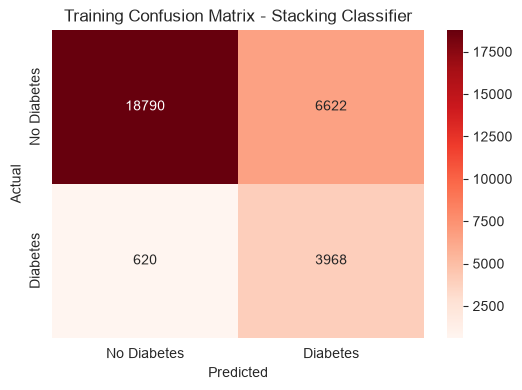

Training Confusion Matrix Breakdown
True Negatives:  18790
False Positives: 6622
False Negatives: 620
True Positives:  3968


In [69]:
train_cm = confusion_matrix(y_train_sub, y_train_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    train_cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title(f"Training Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

tn_train, fp_train, fn_train, tp_train = train_cm.ravel()

print("Training Confusion Matrix Breakdown")
print("True Negatives", tn_train)
print("False Positives", fp_train)
print("False Negatives", fn_train)
print("True Positives", tp_train)

In [70]:
y_test_pred = model.predict(X_test_scaled)
y_test_prob_all = model.predict_proba(X_test_scaled)
y_test_prob = y_test_prob_all[:, 1]

test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

print("Test Accuracy", round(test_acc, 4))
print("Precision", round(test_precision, 4))
print("Recall", round(test_recall, 4))
print("F1-score", round(test_f1, 4))
print("ROC AUC", round(test_roc_auc, 4))

print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

Test Accuracy: 0.7190
Precision: 0.3204
Recall: 0.7473
F1-score: 0.4485
ROC AUC: 0.8079

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9399    0.7138    0.8114     48595
           1     0.3204    0.7473    0.4485      8774

    accuracy                         0.7190     57369
   macro avg     0.6302    0.7306    0.6300     57369
weighted avg     0.8452    0.7190    0.7559     57369



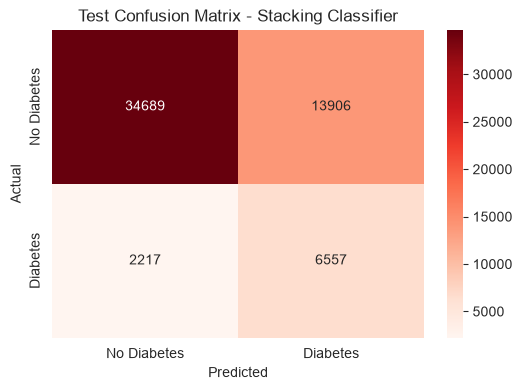

Test Confusion Matrix Breakdown
True Negatives:  34689
False Positives: 13906
False Negatives: 2217
True Positives:  6557


In [71]:
test_cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title(f"Test Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = test_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Test Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

### Observation

The Stacking Classifier achieved a test accuracy of 0.719 and recall of 0.747 on Feature Set C, with 2,217 false negatives. It balanced recall and precision well, reaching 0.320 precision and 0.449 F1-score, which made it one of the more stable ensemble models. ROC AUC was 0.808, showing strong overall discrimination between classes.

Compared with Feature Set A (recall 0.747, 2,217 false negatives) and Feature Set B (recall 0.748, 2,214 false negatives), performance was nearly identical. The reduced feature set did not change results much, suggesting the ensemble's strength comes from combining models rather than the number of features.

Overall, the Stacking Classifier provided the most balanced ensemble performance on Feature Set C. It did not reach the top recall but maintained solid accuracy and reliability, making it a strong all-rounder for screening use.


In [72]:
stacking_results_c = {
    'Feature Set': 'C',
    'Model': model_name,
    'Training Accuracy': train_acc,
    'Test Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1-score': test_f1,
    'ROC AUC': test_roc_auc,
    'False Positives': fp,
    'False Negatives': fn
}

all_results.append(stacking_results_c)
pd.DataFrame(all_results).round(4)

,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,C,Logistic Regression,0.7160,0.7139,0.3172,0.7554,0.4468,0.8070,14267,2146
1,C,Linear SVM,0.7122,0.7096,0.3142,0.7603,0.4447,0.8067,14558,2103
2,C,RBF SVM,0.7140,0.6994,0.3082,0.7760,0.4412,0.7984,15281,1965
3,C,Gaussian Naive Bayes,0.7631,0.7637,0.3328,0.5426,0.4125,0.7741,9546,4013
4,C,Balanced Random Forest,0.8868,0.4206,0.2000,0.9295,0.3291,0.7057,32623,619
5,C,Balanced Bagging,0.7227,0.7103,0.3165,0.7710,0.4487,0.8116,14612,2009
6,C,Easy Ensemble,0.7221,0.1529,0.1529,1.0000,0.2653,0.7373,48595,0
7,C,Voting Classifier,0.8339,0.7725,0.3540,0.5913,0.4429,0.7967,9468,3586
8,C,Stacking Classifier,0.7586,0.7190,0.3204,0.7473,0.4485,0.8079,13906,2217


In [73]:
results_c = pd.DataFrame(all_results).round(4)

results_c = results_c.sort_values(
    by=['Recall', 'False Negatives'],
    ascending=[False, True]
).reset_index(drop=True)

results_c

,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,C,Easy Ensemble,0.7221,0.1529,0.1529,1.0000,0.2653,0.7373,48595,0
1,C,Balanced Random Forest,0.8868,0.4206,0.2000,0.9295,0.3291,0.7057,32623,619
2,C,RBF SVM,0.7140,0.6994,0.3082,0.7760,0.4412,0.7984,15281,1965
3,C,Balanced Bagging,0.7227,0.7103,0.3165,0.7710,0.4487,0.8116,14612,2009
4,C,Linear SVM,0.7122,0.7096,0.3142,0.7603,0.4447,0.8067,14558,2103
5,C,Logistic Regression,0.7160,0.7139,0.3172,0.7554,0.4468,0.8070,14267,2146
6,C,Stacking Classifier,0.7586,0.7190,0.3204,0.7473,0.4485,0.8079,13906,2217
7,C,Voting Classifier,0.8339,0.7725,0.3540,0.5913,0.4429,0.7967,9468,3586
8,C,Gaussian Naive Bayes,0.7631,0.7637,0.3328,0.5426,0.4125,0.7741,9546,4013


In [74]:
results_c.to_csv('all_model_results_c.csv', index=False)
print('Saved: all_model_results_c.csv')

Saved: all_model_results_c.csv


## 6.0 Feature Set C - Summary and Conclusions


Feature Set C used a reduced group of 14 predictors to test whether a smaller, cleaner feature set could still perform well. The goal was to see if simplifying the input could maintain strong recall while improving generalisation and reducing complexity. Overall, most models stayed about the same or dropped slightly compared with Feature Sets A and B. The important exception is RBF SVM, which edged ahead on recall and false negatives and became the strongest practical result in the project.

### Model Comparison Table

| Feature Set | Model | Training Accuracy | Test Accuracy | Precision | Recall | F1-score | ROC AUC |
|--------------|--------|------------------|---------------|------------|---------|-----------|----------|
| C | Logistic Regression | 0.7160 | 0.7139 | 0.3172 | 0.7554 | 0.4468 | 0.8070 |
| C | Linear SVM | 0.7122 | 0.7096 | 0.3142 | 0.7603 | 0.4447 | 0.8067 |
| C | RBF SVM | 0.7140 | 0.6994 | 0.3082 | 0.7760 | 0.4412 | 0.7984 |
| C | Gaussian Naive Bayes | 0.7631 | 0.7637 | 0.3328 | 0.5426 | 0.4125 | 0.7741 |
| C | Balanced Random Forest | 0.8868 | 0.4206 | 0.2000 | 0.9295 | 0.3291 | 0.7057 |
| C | Balanced Bagging | 0.7227 | 0.7103 | 0.3165 | 0.7710 | 0.4487 | 0.8116 |
| C | Easy Ensemble | 0.7221 | 0.1529 | 0.1529 | 1.0000 | 0.2653 | 0.7373 |
| C | Voting Classifier | 0.8339 | 0.7725 | 0.3540 | 0.5913 | 0.4429 | 0.7967 |
| C | Stacking Classifier | 0.7586 | 0.7190 | 0.3204 | 0.7473 | 0.4485 | 0.8079 |

### Summary

RBF SVM performed best overall for Feature Set C on the metrics that matter most for this project. It achieved the highest recall (0.7760) and the fewest false negatives (1,965) among the practical models. Balanced Bagging was very close behind (recall 0.7710, 2,009 false negatives). Logistic regression and Linear SVM followed closely, showing that simpler models still generalise well even with fewer features. Stacking Classifier also performed consistently, balancing recall and precision without major changes from the earlier sets.

Balanced Random Forest and Easy Ensemble pushed recall extremely high (0.93 and 1.00 respectively) but produced far too many false positives, making them impractical for screening. Voting Classifier achieved the best accuracy (0.77) and precision (0.35) but missed more diabetes cases, showing the trade-off between sensitivity and reliability. Gaussian Naive Bayes remained the weakest for recall, confirming that it struggles when the screening objective is catching positive cases.

### What I took away from Feature Set C

1. RBF SVM was the strongest model for minimising false negatives on Feature Set C. It achieved the highest recall (0.7760) and fewest false negatives (1,965), and this was also the best practical result across Feature Sets A, B, and C.
2. Balanced Bagging was a very close alternative (recall 0.7710, 2,009 false negatives).
3. Linear SVM and logistic regression were solid alternatives. Their results were close to the top models, showing simpler models still perform well.
4. Stacking Classifier was the best ensemble overall. It provided the most balanced performance across recall, precision, and ROC AUC.
5. Voting Classifier improved accuracy but missed more cases. It was less effective for recall-focused screening.
6. Balanced Random Forest and Easy Ensemble showed the risk of pushing recall too far. They caught nearly all cases but created too many false alarms.
7. Gaussian Naive Bayes was fast but weaker on recall. It is useful as a benchmark but not for screening.
8. Reducing features did not hurt the best model. The smaller set still performed as well as, and for RBF SVM slightly better than, Feature Sets A and B.

### Conclusion

For diabetes screening using Feature Set C, RBF SVM would be my first choice if the main goal is to minimise false negatives. It achieved the highest recall (0.7760) and missed the fewest diabetes cases (1,965) among the practical models tested.

Balanced Bagging is a very close alternative (recall 0.7710, 2,009 false negatives) and remains a strong screening option.

If the goal is to choose the best ensemble model overall, then Stacking Classifier would be the best choice. It did not achieve the top recall but provided the best overall balance across recall, F1-score, ROC AUC, and general model behaviour.

Feature Set C confirmed that reducing the number of predictors did not clearly hurt performance. The smaller 14-feature set still performed as well as the larger feature sets, and with RBF SVM it produced the strongest practical screening result in the project. That is useful for simpler deployment and interpretation.
